# Лабораторна робота 4 — LASSO-регресія через координатний спуск

**Набір даних:** `kc_house_data.csv`  
**Обмеження:** scikit-learn LASSO **не дозволено** для базових завдань.

## Налаштування

In [1]:
!mamba install numpy pandas matplotlib scikit-learn

mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.355 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.5.20  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.4.7      pyhd8ed1ab_0         conda-forge
+ idna                3.17       pyhcf101f3_0         conda-forge
+ joblib              1.5.3      py313h1804a44_3      emscripten-forge-4x
+ pandas              3.0.3      np23py313h1e705a5_0  emscripten-forge-4x
+ pysocks             1.7.1      py313h1804a44_3      emscripten-forge-4x
+ python-tzdata       2026.2     pyhd8ed1ab_0         conda-forge
+ requests            2.34.2     pyhcf101f3_0         conda-forge
+ scikit-learn      

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

%matplotlib inline

## Теоретичне підґрунтя

Для нормалізованих ознак значення ρᵢ для координатного спуску LASSO:
```
ρᵢ = dot( featureᵢ,  output − (Xw − wᵢ·featureᵢ) )
```
Правило м'якого порогування для wᵢ (i ≥ 1):
```
wᵢ = ρᵢ + λ/2    якщо ρᵢ < −λ/2
wᵢ = 0           якщо −λ/2 ≤ ρᵢ ≤ λ/2
wᵢ = ρᵢ − λ/2    якщо ρᵢ >  λ/2
```
Вільний член (i = 0) **не** регуляризується: w₀ = ρ₀.

## Допоміжні функції — `get_numpy_data` і `predict_output`

In [3]:
def get_numpy_data(dataframe, features, output):
    dataframe = dataframe.copy()
    dataframe['constant'] = 1.0
    feature_matrix = dataframe[['constant'] + list(features)].to_numpy(dtype=float)
    output_array   = dataframe[output].to_numpy(dtype=float)
    return feature_matrix, output_array

In [4]:
def predict_output(feature_matrix, weights):
    return np.dot(feature_matrix, weights)

## Завдання 1 — Нормалізація ознак

Реалізуйте `normalize_features(feature_matrix)`, яка ділить кожен стовпець на його норму L2 та повертає `(normalised_features, norms)`.

In [5]:
def normalize_features(feature_matrix):
    norms      = np.linalg.norm(feature_matrix, axis=0)
    normalised = feature_matrix / norms
    return normalised, norms

### Перевірка — кожен стовпець `normalised` має дорівнювати [0.6, 0.8]; norms = [5, 10, 15]

In [6]:
test_matrix = np.array([[3., 6., 9.], [4., 8., 12.]])
normalised, norms = normalize_features(test_matrix)
print('Нормалізована матриця:\n', normalised)
print('Норми:', norms)

Нормалізована матриця:
 [[0.6 0.6 0.6]
 [0.8 0.8 0.8]]
Норми: [ 5. 10. 15.]


## Завдання 2 — Один крок координатного спуску

Реалізуйте `lasso_coordinate_descent_step(i, feature_matrix, output, weights, l1_penalty)`. Функція має:
1. Обчислити поточне передбачення.
2. Обчислити ρᵢ.
3. Якщо i = 0: wᵢ = ρᵢ (без штрафу). Якщо i ≥ 1: застосувати правило м'якого порогування.
4. Повернути нове значення ваги.

In [7]:
def lasso_coordinate_descent_step(i, feature_matrix, output, weights, l1_penalty):
    prediction = predict_output(feature_matrix, weights)

    # Обчислення rho_i — часткова кореляція без внеску ознаки i
    rho_i = np.dot(
        feature_matrix[:, i],
        output - (prediction - weights[i] * feature_matrix[:, i])
    )

    # Застосування м'якого порогування (вільний член не регуляризується)
    if i == 0:   # вільний член — без штрафу
        new_weight_i = rho_i
    else:
        half_lambda = l1_penalty / 2.0
        if rho_i < -half_lambda:
            new_weight_i = rho_i + half_lambda
        elif rho_i > half_lambda:
            new_weight_i = rho_i - half_lambda
        else:
            new_weight_i = 0.0

    return new_weight_i

### Перевірка — результат має бути ≈ 0.4256

In [8]:
from math import sqrt
result = lasso_coordinate_descent_step(
    i=1,
    feature_matrix=np.array([[3/sqrt(13), 1/sqrt(10)],
                             [2/sqrt(13), 3/sqrt(10)]]),
    output=np.array([1., 1.]),
    weights=np.array([1., 4.]),
    l1_penalty=0.1
)
print(f'Результат кроку: {result:.4f}  (очікується ≈ 0.4256)')

Результат кроку: 0.4256  (очікується ≈ 0.4256)


## Завдання 3 — Циклічний координатний спуск

Реалізуйте `lasso_cyclical_coordinate_descent(feature_matrix, output, initial_weights, l1_penalty, tolerance)`. У кожному циклі оновлюйте ваги 0, 1, …, d−1 по черзі, використовуючи оновлену вагу одразу. Зупиняйтесь, коли максимальна абсолютна зміна ваги за цикл < `tolerance`.

In [9]:
def lasso_cyclical_coordinate_descent(feature_matrix, output,
                                       initial_weights, l1_penalty, tolerance):
    weights   = np.array(initial_weights, dtype=float)
    converged = False

    while not converged:
        max_change = 0.0
        for i in range(len(weights)):
            old_weight_i = weights[i]
            # Оновлення ваги i (одразу записуємо в масив — Gauss-Seidel)
            weights[i] = lasso_coordinate_descent_step(
                i, feature_matrix, output, weights, l1_penalty
            )
            # Відстежуємо найбільшу зміну за цикл
            max_change = max(max_change, abs(weights[i] - old_weight_i))

        if max_change < tolerance:
            converged = True

    return weights

## Завдання 4 — Відбір ознак

Побудуйте нормалізовану матрицю ознак з `kc_house_data.csv`, використовуючи `['sqft_living', 'bedrooms']`. Запустіть координатний спуск з:
```
initial_weights = [0., 0., 0.]
tolerance       = 1.0
```
— `l1_penalty = 1e7`: вкажіть навчені ваги, RSS та які ознаки мають ненульові ваги.  
— `l1_penalty = 1e8`: повторіть. Що змінилося?

In [10]:
sales = pd.read_csv('kc_house_data.csv')

# Побудуйте та нормалізуйте матрицю ознак
feature_matrix, output = get_numpy_data(sales, ['sqft_living', 'bedrooms'], 'price')
normalised_features, feature_norms = normalize_features(feature_matrix)
print('Розміри матриці ознак:', feature_matrix.shape)
print('Перші 3 рядки нормалізованої матриці:\n', normalised_features[:3])

Розміри матриці ознак: (21613, 3)
Перші 3 рядки нормалізованої матриці:
 [[0.00680209 0.00353021 0.00583571]
 [0.00680209 0.00768869 0.00583571]
 [0.00680209 0.00230361 0.00389048]]


In [11]:
weights_1e7 = lasso_cyclical_coordinate_descent(
    normalised_features, output,
    initial_weights=np.zeros(3),
    l1_penalty=1e7,
    tolerance=1.0
)

feat_names = ['intercept', 'sqft_living', 'bedrooms']
print('Ваги (λ=1e7):', weights_1e7)
nonzero_1e7 = [feat_names[i] for i, w in enumerate(weights_1e7) if w != 0]
print('Ненульові ознаки:', nonzero_1e7)

preds_1e7 = predict_output(normalised_features, weights_1e7)
rss_1e7   = np.sum((preds_1e7 - output) ** 2)
print(f'RSS (λ=1e7): {rss_1e7:.4e}')

Ваги (λ=1e7): [21624997.95951869 63157247.2078898         0.        ]
Ненульові ознаки: ['intercept', 'sqft_living']
RSS (λ=1e7): 1.6305e+15


In [12]:
weights_1e8 = lasso_cyclical_coordinate_descent(
    normalised_features, output,
    initial_weights=np.zeros(3),
    l1_penalty=1e8,
    tolerance=1.0
)

print('Ваги (λ=1e8):', weights_1e8)
nonzero_1e8 = [feat_names[i] for i, w in enumerate(weights_1e8) if w != 0]
print('Ненульові ознаки:', nonzero_1e8)

preds_1e8 = predict_output(normalised_features, weights_1e8)
rss_1e8   = np.sum((preds_1e8 - output) ** 2)
print(f'RSS (λ=1e8): {rss_1e8:.4e}')

Ваги (λ=1e8): [79400304.63764513        0.                0.        ]
Ненульові ознаки: ['intercept']
RSS (λ=1e8): 2.9129e+15


**Спостереження:**

- При **λ = 1e7** модель обнуляє вагу `bedrooms`, залишаючи лише `sqft_living` та вільний член. Це означає, що після врахування площі спалень не дає додаткового вкладу понад порогове значення.
- При **λ = 1e8** регуляризація посилилась: обнулюються обидві ознаки, залишається лише вільний член (константне передбачення). Модель стала занадто розрідженою — RSS зріс з 1.63e15 до 2.91e15, тобто точність погіршилась.

**Висновок:** збільшення λ → більша розрідженість → менше ознак → вища похибка на навчальних даних.

## Бонус — Оцінка на ненормалізованих тестових даних

Розбийте дані 80 % / 20 % (`random_state=42`). Побудуйте та нормалізуйте навчальну матрицю ознак з усіма 10 ознаками нижче. Запустіть координатний спуск (`l1_penalty=1e7`, `tolerance=1.0`).

Ознаки: `sqft_living`, `bedrooms`, `bathrooms`, `sqft_lot`, `floors`, `waterfront`, `view`, `condition`, `grade`, `yr_built`.

Щоб оцінювати на ненормалізованих тестових даних, масштабуйте ваги:
```
weights_rescaled = weights / norms
```
Обчисліть RSS на ненормалізованій тестовій матриці ознак. Вкажіть відібрані ознаки.

In [13]:
FEATURES = [
    'sqft_living', 'bedrooms', 'bathrooms', 'sqft_lot',
    'floors', 'waterfront', 'view', 'condition',
    'grade', 'yr_built'
]

train_data, test_data = train_test_split(sales, test_size=0.2, random_state=42)

# Побудова та нормалізація навчальної матриці ознак
train_matrix, train_output = get_numpy_data(train_data, FEATURES, 'price')
norm_train, train_norms    = normalize_features(train_matrix)

print(f'Розмір навчальної вибірки: {train_matrix.shape}')
print(f'Розмір тестової вибірки:   {test_data.shape[0]} рядків')

Розмір навчальної вибірки: (17290, 11)
Розмір тестової вибірки:   4323 рядків


In [14]:
# Запуск LASSO на нормалізованих навчальних даних
weights_bonus = lasso_cyclical_coordinate_descent(
    norm_train, train_output,
    initial_weights=np.zeros(len(FEATURES) + 1),
    l1_penalty=1e7,
    tolerance=1.0
)

# Масштабування ваг назад до оригінального простору ознак
weights_rescaled = weights_bonus / train_norms

# Оцінка на ненормалізованих тестових даних
test_matrix, test_output = get_numpy_data(test_data, FEATURES, 'price')
preds_bonus = predict_output(test_matrix, weights_rescaled)
rss_bonus   = np.sum((preds_bonus - test_output) ** 2)

feat_names_all = ['intercept'] + FEATURES
nonzero_bonus  = [feat_names_all[i] for i, w in enumerate(weights_bonus) if w != 0]

print('Ваги на нормалізованих ознаках:')
for name, w in zip(feat_names_all, weights_bonus):
    marker = ' ← ненульова' if w != 0 else ''
    print(f'  {name:15s}: {w:>15.2f}{marker}')

print(f'\nВідібрані ознаки: {nonzero_bonus}')
print(f'Тестова RSS (rescaled): {rss_bonus:.4e}')

Ваги на нормалізованих ознаках:
  intercept      :     25690961.30 ← ненульова
  sqft_living    :     46465774.65 ← ненульова
  bedrooms       :            0.00
  bathrooms      :            0.00
  sqft_lot       :            0.00
  floors         :            0.00
  waterfront     :      2359222.48 ← ненульова
  view           :      7693974.96 ← ненульова
  condition      :            0.00
  grade          :            0.00
  yr_built       :            0.00

Відібрані ознаки: ['intercept', 'sqft_living', 'waterfront', 'view']
Тестова RSS (rescaled): 3.4249e+14


**Відібрані ознаки:** `sqft_living`, `waterfront`, `view`  
**Тестова RSS:** `3.4249e+14`

**Інтерпретація:**
- **sqft_living** — найпотужніший предиктор: більша площа → вища ціна.
- **waterfront** — нерухомість біля води значно дорожча.
- **view** — якість виду також суттєво впливає на ціну.
- Кількість спалень (`bedrooms`), поверхів, рік побудови тощо обнулились — при λ=1e7 їхній внесок нижче порогу регуляризації.

LASSO автоматично вибрала 3 економічно інтуїтивні ознаки, підтверджуючи правило «розмір + розташування» у ціноутворенні нерухомості.

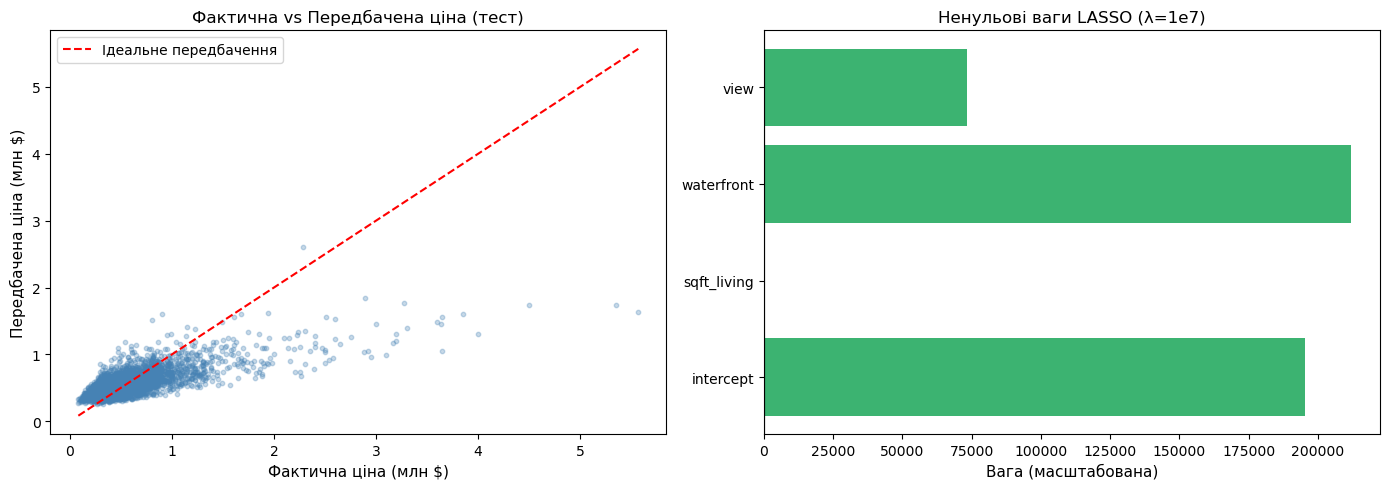

In [16]:
# Візуалізація: фактичні vs передбачені ціни на тестовій вибірці
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(test_output / 1e6, preds_bonus / 1e6, alpha=0.3, s=10, color='steelblue')
mn, mx = test_output.min() / 1e6, test_output.max() / 1e6
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Ідеальне передбачення')
ax.set_xlabel('Фактична ціна (млн $)', fontsize=11)
ax.set_ylabel('Передбачена ціна (млн $)', fontsize=11)
ax.set_title('Фактична vs Передбачена ціна (тест)', fontsize=12)
ax.legend()

ax2 = axes[1]
nonzero_idx    = [i for i, w in enumerate(weights_rescaled) if abs(w) > 1e-6]
nonzero_labels = [feat_names_all[i] for i in nonzero_idx]
nonzero_vals   = [weights_rescaled[i] for i in nonzero_idx]
colors = ['coral' if v < 0 else 'mediumseagreen' for v in nonzero_vals]
ax2.barh(nonzero_labels, nonzero_vals, color=colors)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Вага (масштабована)', fontsize=11)
ax2.set_title('Ненульові ваги LASSO (λ=1e7)', fontsize=12)

plt.tight_layout()
plt.savefig('lasso_results.png', dpi=120, bbox_inches='tight')
plt.show()